<a href="https://colab.research.google.com/github/luigi-radicchi/luigi-radicchi/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [135]:
# load the csv file into dataframe variable df
df = pd.read_csv('messy_IMDB_dataset.csv', encoding = 'latin1', sep = ';')
df_backup = df

In [136]:
# initial dataframe analysis
print(df.shape)
print('\n')
print(df.info())

(101, 12)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IMBD title ID   100 non-null    object 
 1   Original titlÊ  100 non-null    object 
 2   Release year    100 non-null    object 
 3   Genrë¨          100 non-null    object 
 4   Duration        99 non-null     object 
 5   Country         100 non-null    object 
 6   Content Rating  77 non-null     object 
 7   Director        100 non-null    object 
 8   Unnamed: 8      0 non-null      float64
 9   Income          100 non-null    object 
 10   Votes          100 non-null    object 
 11  Score           100 non-null    object 
dtypes: float64(1), object(11)
memory usage: 9.6+ KB
None


In [137]:
# handling 'Unnamed: 8' column as an empty column
print(df['Unnamed: 8'])
empty_count = df['Unnamed: 8'].isnull().sum()
print('Empty counts in this column: ' + str(empty_count))
# delete column
df = df.drop(columns = 'Unnamed: 8', axis = 1)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
96    NaN
97    NaN
98    NaN
99    NaN
100   NaN
Name: Unnamed: 8, Length: 101, dtype: float64
Empty counts in this column: 101


In [138]:
# cleaning the titles of the column
df = df.rename(columns={'Original titlÊ': 'Original Title', 'Genrë¨': 'Genre', ' Votes ': 'Votes'})

In [139]:
# identifying the missing line
df_null = df.isnull()
df_null = df_null[df_null['Original Title'] == True]
df_null
# line 13 to be deleted

,IMBD title ID,Original Title,Release year,Genre,Duration,Country,Content Rating,Director,Income,Votes,Score
13,True,True,True,True,True,True,True,True,True,True,True


In [140]:
# delete the empty line
df = df.dropna(subset = 'IMBD title ID', axis = 0)

In [141]:
# identifying the missing value for duration
df_null = df.isnull()
df_null = df_null[df_null['Duration'] == True]
# line 14, corresponding to The Matrix with a duration of 136 minutes
df.loc[14, 'Duration'] = 136

In [142]:
# define a function and create a boolean column to detect errors in the duration entry

def check_minutes(x):
  x = str(x)
  char_len = len(x)
  if char_len == 3 and (x[0] == '1' or x[0] == '2'):
    x = 'OK'
  elif char_len == 2 and (x[0] == '9' or x[0] == '8' or x[0] == '7'):
    x = 'OK'
  else:
    x = 'CHECK'
  return x

df['Prova'] = df['Duration'].apply(check_minutes)

df[df['Prova'] == 'CHECK']
# six movies have erroneous value entries, it is possible to replace them by dictionary

,IMBD title ID,Original Title,Release year,Genre,Duration,Country,Content Rating,Director,Income,Votes,Score,Prova
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,$ 222831817,1.780.147,"8,9f",CHECK
6,tt0108052,Schindler's List,1994-03-11,"Biography, Drama, History",Nan,USA,R,Steven Spielberg,$ 322287794,1.183.248,8.9,CHECK
9,tt0137523,Fight Club,10-29-99,Drama,Inf,UK,R,David Fincher,$ 101218804,1.807.440,8.8,CHECK
11,tt0120737,The Lord of the Rings: The Fellowship of the Ring,2002-01-18,"Action, Adventure, Drama",178c,New Zesland,PG-13,Peter Jackson,$ 887934303,1.619.920,8.8,CHECK
16,tt0080684,Star Wars: Episode V - The Empire Strikes Back,1980-09-19,"Action, Adventure, Fantasy",Not Applicable,USA,PG,Irvin Kershner,$ 549265501,1.132.073,"8,7e-0",CHECK
18,tt0073486,One Flew Over the Cuckoo's Nest,18/11/1976,Drama,-,USA,R,Milos Forman,$ 108997629,891.071,8.7,CHECK


In [143]:
# Replace the values with the exact movie lengths taken by web, use a dictionar since the erroneous entries are different
df = df.drop(columns='Prova')
replace_dictionary = {' ':'154',
                      'Nan':'195',
                      'Inf':'139',
                      '178c':'178',
                      'Not Applicable':'124',
                      '-': '133'}
df['Duration'] = df['Duration'].replace(replace_dictionary)

# change the type of the Duration column to int64
df['Duration'] = df['Duration'].astype('int64')


In [144]:
# cleaning Release year column
# identify the rows that are not in yyyy-mm-dd format

def date_format_check(x):
  if x[4] == '-' and x[7] == '-' and len(x) == 10:
    x = 'OK'
  else:
    x = 'CHECK'
  return x

df['RY_check'] = df['Release year'].apply(date_format_check)
df[df['RY_check'] == 'CHECK']
# nine movies with erroneous date entry have been found

,IMBD title ID,Original Title,Release year,Genre,Duration,Country,Content Rating,Director,Income,Votes,Score,RY_check
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,$ 246120974,1.572.674,9.2,CHECK
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,$ 1005455211,2.241.615,9.,CHECK
5,tt0167260,The Lord of the Rings: The Return of the King,22 Feb 04,"Action, Adventure, Drama",201,New Zealand,PG-13,Peter Jackson,$ 1142271098,1.604.280,08.9,CHECK
9,tt0137523,Fight Club,10-29-99,Drama,139,UK,R,David Fincher,$ 101218804,1.807.440,8.8,CHECK
12,tt0060196,"Il buono, il brutto, il cattivo",23rd December of 1966,Western,161,Italy,Approved,Sergio Leone,$ 25252481,672.499,8.8,CHECK
15,tt0167261,The Lord of the Rings: The Two Towers,01/16-03,"Action, Adventure, Drama",179,New Zeland,PG-13,Peter Jackson,$ 951227416,1.449.778,8.7.,CHECK
18,tt0073486,One Flew Over the Cuckoo's Nest,18/11/1976,Drama,133,USA,R,Milos Forman,$ 108997629,891.071,8.7,CHECK
45,tt0034583,Casablanca,21-11-46,"Drama, Romance, War",102,USA,PG,Michael Curtiz,$ 4374761,509.953,8.3,CHECK
70,tt0043014,Sunset Blvd.,"The 6th of marzo, year 1951","Drama, Film-Noir",110,USA,NaN,Billy Wilder,$ 299645,195.789,8.0,CHECK


In [145]:
# Since there are few errors and the type is different for each one a replacement dictionary will be used
df = df.drop(columns='RY_check')

replace_dictionary = {' 23 -07-2008':'2008-07-23',
                      '01/16-03':'2003-01-16',
                      '09 21 1972':'1972-09-21',
                      '10-29-99':'1999-10-29',
                      '18/11/1976':'1976-11-18',
                      '21-11-46': '1946-11-21',
                      '22 Feb 04': '2004-02-22',
                      '23rd December of 1966 ': '1966-12-23',
                      'The 6th of marzo, year 1951': '1951-03-06',
                      '1984-02-34': '1984-02-01',
                      '1976-13-24' : '1976-12-24'}
df['Release year'] = df['Release year'].replace(replace_dictionary)

# convert the column to datetime
df['Release year'] = df['Release year'].astype('string')
df['Release year'] = pd.to_datetime(df['Release year'])

# rename column to date and create year release
df = df.rename(columns={'Release year': 'Release Date'})
df['Release Year'] = df['Release Date'].dt.year

In [146]:
# clean the Country column
set(df['Country'])

def country_cleaner(x):
  if x[0:2] == 'US':
    x = 'USA'

  if x[0:3] == 'New':
    x = 'New Zealand'

  if x == 'Italy1':
    x = 'Italy'
  return x

df['Country'] = df['Country'].apply(country_cleaner)



In [147]:
# cleaning the content rate column
#df.drop(columns = 'Rating_isnull', inplace = True)
set(df['Content Rating'])
df['Content Rating'] = df['Content Rating'].replace('Unrated', 'Not Rated')
df['Content Rating'] = df['Content Rating'].replace('Approved', 'G')
df['Content Rating'] = df['Content Rating'].replace('nan', 'Not Rated')
df['Content Rating'].fillna('Not Rated', inplace = True)



/tmp/ipykernel_2072/3724891201.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Content Rating'].fillna('Not Rated', inplace = True)


In [148]:
# cleaning the income column
set(df['Income'])

def income_cleaner(x):
  x = str(x)
  x = x.replace('$ ','')
  x = x.replace('o', '0')
  x = x.replace(',', '')
  return x

df['Income'] = df['Income'].apply(income_cleaner)

# convert the Income to int
df['Income'] = df['Income'].astype('int64')

In [149]:
# cleaning the votes column
set(df['Votes'])

def votes_cleaner(x):
  x = str(x)
  x = x.replace('.', '')
  return x

df['Votes'] = df['Votes'].apply(votes_cleaner)

# convert the votes to int
df['Votes'] = df['Votes'].astype('int64')



In [150]:
# cleaning the score column
set(df['Score'])

def score_cleaner(x):
  x = str(x)
  x = x.replace(',', '.')
  x = x.replace('+','')
  x = x.replace('-','')
  x = x.replace('e','')
  x = x.replace('f','')
  x = x.replace('..','.')
  x = x.replace(':','.')
  if x[0] == '0':
    x = x[1:]

  if x[len(x)-1] == '0':
    x = x[:-1]

  if len(x) == 2 and x[1] == '.':
    x = x + '0'

  if len(x) > 3 and x[len(x) -1] =='.':
    x = x[:-1]

  return x


df['Score'] = df['Score'].apply(score_cleaner)

# Convert Score to float
df['Score'] = df['Score'].astype('float64')

In [151]:
# check the validation input of the data by visualization
df.describe()

# there are inconstencies with Income column since the range varies from 576 $ to almost 3B $

,Release Date,Duration,Income,Votes,Score,Release Year
count,100,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000
mean,1990-06-25 09:36:00,136.040000,2.991255e+08,8.297713e+05,8.240000,1989.890000
min,1937-03-12 00:00:00,81.000000,5.760000e+02,1.957890e+05,7.400000,1937.000000
25%,1977-08-06 00:00:00,115.000000,2.374174e+07,3.890690e+05,7.900000,1976.750000
50%,1995-08-03 12:00:00,130.000000,1.093370e+08,7.515385e+05,8.300000,1995.000000
75%,2004-12-10 00:00:00,152.250000,4.052080e+08,1.102243e+06,8.600000,2004.250000
max,2020-01-23 00:00:00,229.000000,2.797801e+09,2.278845e+06,9.300000,2020.000000
std,NaN,31.026518,4.360335e+08,4.829340e+05,0.451485,20.486455


<Axes: xlabel='Income', ylabel='Count'>

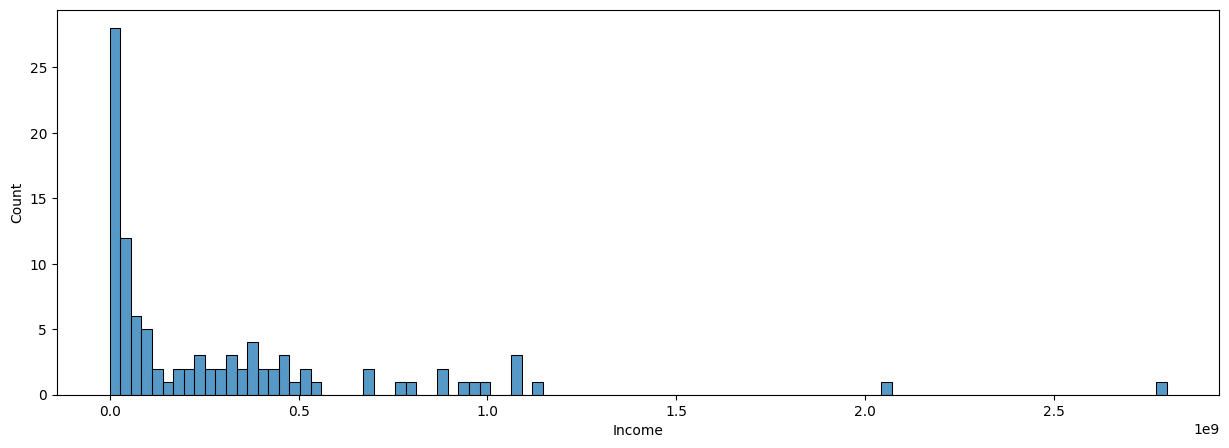

In [152]:
plt.figure(figsize = (15, 5))
sns.histplot(df['Income'], bins = 100)
# the distribution shows 50% under 100M with a certain amount of movies with very low income
# there aro also two clear high outliers

In [153]:
# correcting the movies with the lowest erroneous income
df['Income'] = df['Income'].astype('str')
replace_dictionary = {'576':'1000000',
                      '73446':'13500000',
                      '112911':'5300000',
                      '299645':'2350000',
                      '322773':'805556',
                      '457688': '1800000',
                      '516962': '4700000',
                      '969879': '11000000',
                      '1594107': '1970000',
                      '1864182': '7200000',
                      '1976-13-24' : '1976-12-24'}
df['Income'] = df['Income'].replace(replace_dictionary)
df['Income'] = df['Income'].astype('int64')

In [154]:
# the two upper outliers are Avengers that actually got that huge Income, so no adjustment to make
df.sort_values(by = ['Income'], ascending = True).head()

,IMBD title ID,Original Title,Release Date,Genre,Duration,Country,Content Rating,Director,Income,Votes,Score,Release Year
30,tt0047478,Shichinin no samurai,1955-08-19,"Action, Adventure, Drama",207,Japan,Not Rated,Akira Kurosawa,805556,307958,8.6,1955
7,tt0050083,12 Angry Men,1957-09-04,"Crime, Drama",96,USA,Not Rated,Sidney Lumet,1000000,668473,8.9,1957
49,tt0027977,Modern Times,1937-03-12,"Comedy, Drama, Family",87,USA,G,Charles Chaplin,1800000,211250,8.3,1937
89,tt0033467,Citizen Kane,1948-11-25,"Drama, Mystery",119,USA,Not Rated,Orson Welles,1970000,389322,7.6,1948
70,tt0043014,Sunset Blvd.,1951-03-06,"Drama, Film-Noir",110,USA,Not Rated,Billy Wilder,2350000,195789,8.0,1951


Text(0.5, 1.0, 'Duration boxplot')

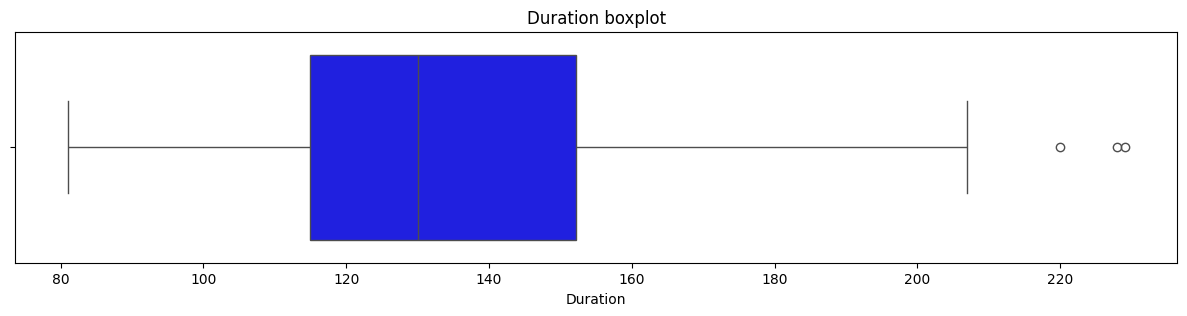

In [155]:
# verifying the distribution of the other numeric entries, Duration, Votes, Score, Release year
import matplotlib.pyplot as plt
import importlib
importlib.reload(plt)
plt.figure(figsize = (15, 3))
sns.boxplot(x = df['Duration'], color = 'blue')
plt.title('Duration boxplot')
# The outliers are Once Upon a Time in America, Lawrence of Arabia, The Godfather: Part II, which are correct values

Text(0.5, 1.0, 'Votes boxplot')

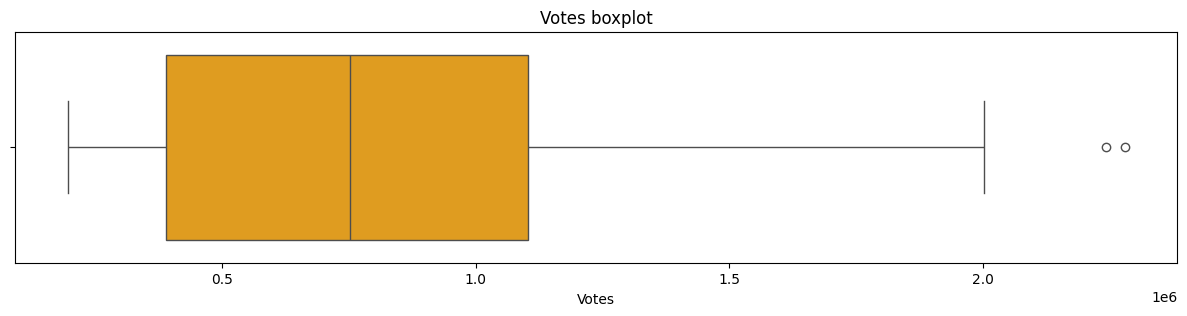

In [156]:
plt.figure(figsize = (15, 3))
sns.boxplot(x = df['Votes'], color = 'orange')
plt.title('Votes boxplot')

Text(0.5, 1.0, 'Scores boxplot')

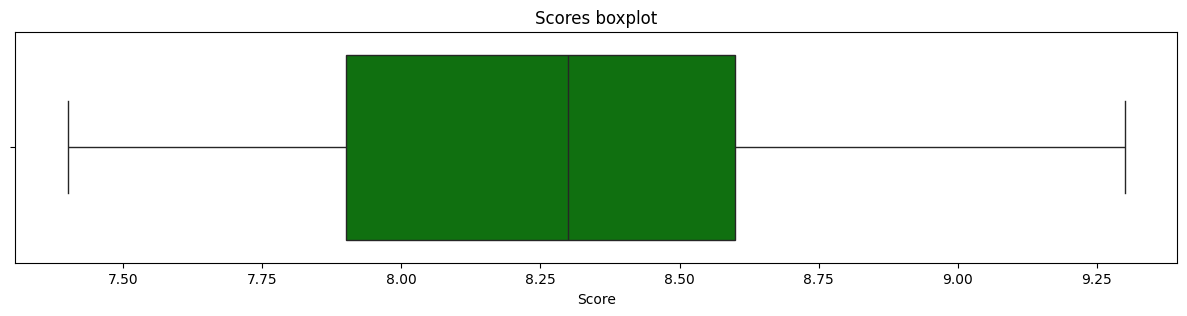

In [157]:
plt.figure(figsize = (15, 3))
sns.boxplot(x = df['Score'], color = 'green')
plt.title('Scores boxplot')

Text(0.5, 1.0, 'Release Year boxplot')

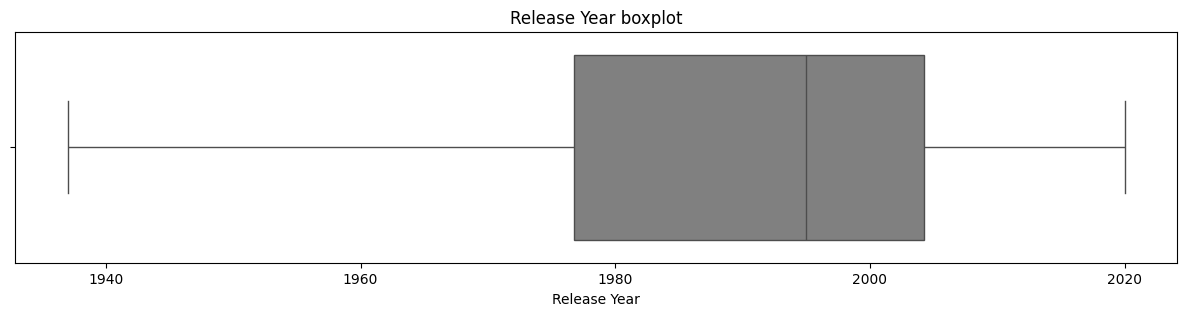

In [158]:
plt.figure(figsize = (15, 3))
sns.boxplot(x = df['Release Year'], color = 'gray')
plt.title('Release Year boxplot')

In [159]:
# final check of the dataframe and export
df.describe()

,Release Date,Duration,Income,Votes,Score,Release Year
count,100,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000
mean,1990-06-25 09:36:00,136.040000,2.995596e+08,8.297713e+05,8.240000,1989.890000
min,1937-03-12 00:00:00,81.000000,8.055560e+05,1.957890e+05,7.400000,1937.000000
25%,1977-08-06 00:00:00,115.000000,2.374174e+07,3.890690e+05,7.900000,1976.750000
50%,1995-08-03 12:00:00,130.000000,1.093370e+08,7.515385e+05,8.300000,1995.000000
75%,2004-12-10 00:00:00,152.250000,4.052080e+08,1.102243e+06,8.600000,2004.250000
max,2020-01-23 00:00:00,229.000000,2.797801e+09,2.278845e+06,9.300000,2020.000000
std,NaN,31.026518,4.357371e+08,4.829340e+05,0.451485,20.486455


In [160]:
df.to_csv('IMDB_cleaned.csv', index = False)

Text(0.5, 1.0, 'Movie score distribution')

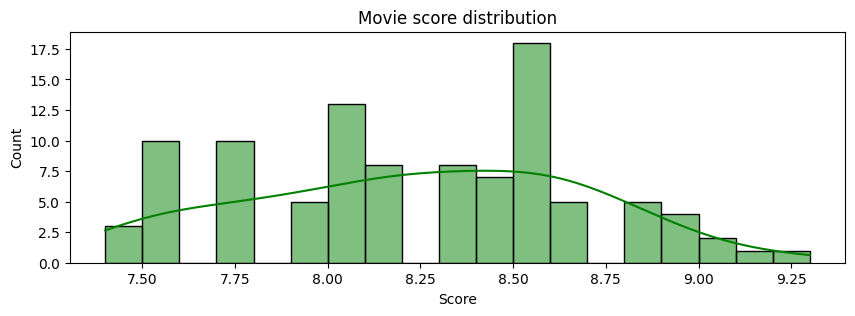

In [161]:
# STARTING WITH EDS
# distribution plot of the numerical values
plt.figure(figsize = (10, 3))
sns.histplot(df['Score'], binwidth = 0.1, kde = True, legend = True, color = 'green')
plt.title('Movie score distribution')

Text(0.5, 1.0, 'Movie release year distribution')

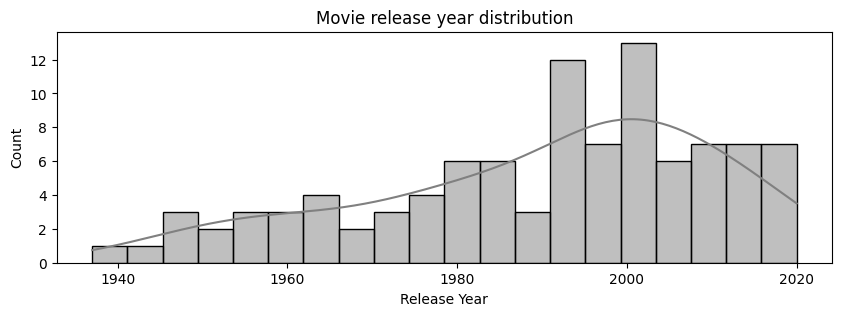

In [162]:
plt.figure(figsize = (10, 3))
sns.histplot(df['Release Year'], bins = 20, kde = True, legend = True, color = 'gray')
plt.title('Movie release year distribution')

Text(0.5, 1.0, 'Movie votes distribution')

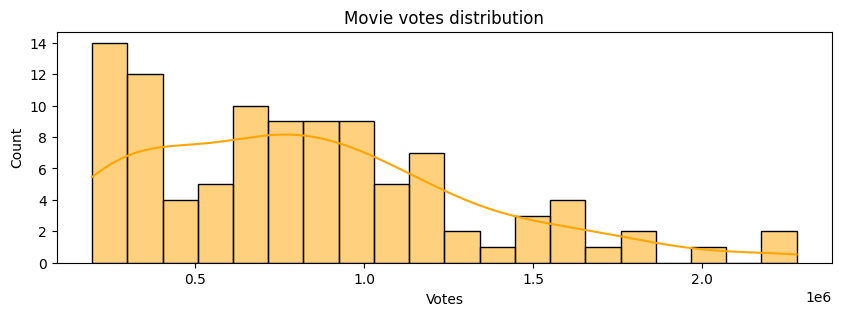

In [163]:
plt.figure(figsize = (10, 3))
sns.histplot(df['Votes'], bins = 20, kde = True, legend = True, color = 'orange')
plt.title('Movie votes distribution')

Text(0.5, 1.0, 'Movie duration distribution in minutes')

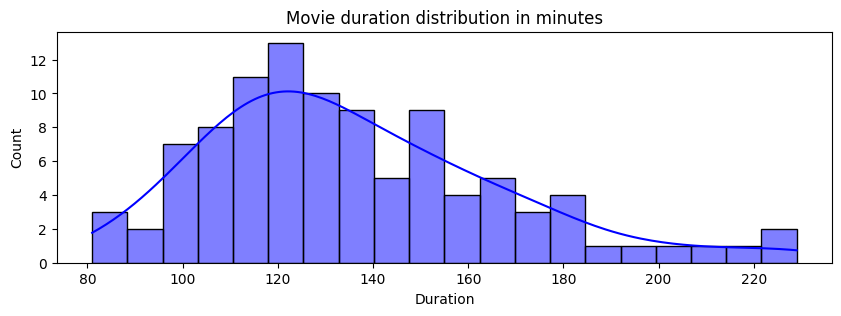

In [164]:
plt.figure(figsize = (10, 3))
sns.histplot(df['Duration'], bins = 20, kde = True, legend = True, color = 'blue')
plt.title('Movie duration distribution in minutes')

<Axes: xlabel='Income', ylabel='Count'>

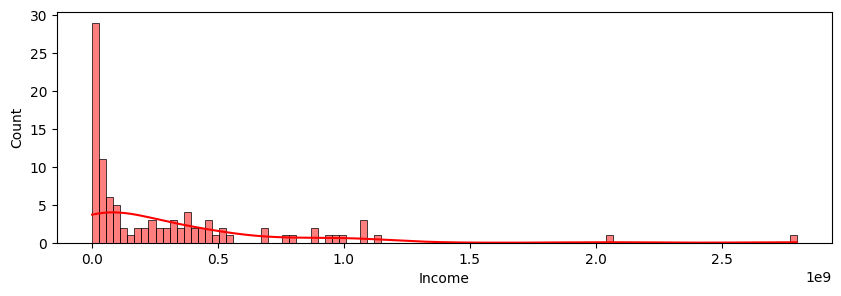

In [165]:
plt.figure(figsize = (10, 3))
sns.histplot(df['Income'], bins = 100, kde = True, legend = True, color = 'red')

Text(0.5, 1.0, 'Top countries for movie production')

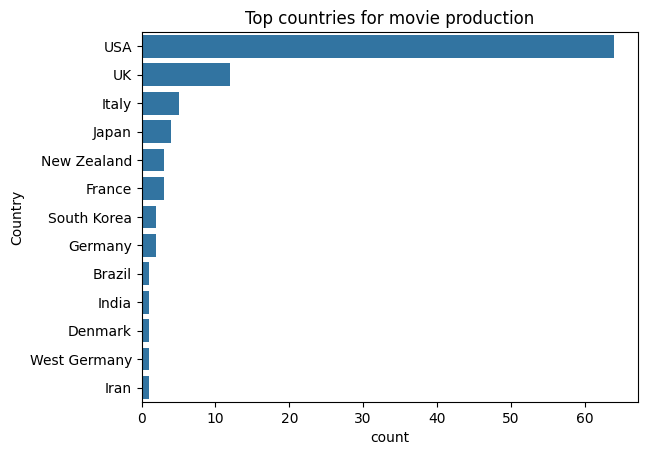

In [166]:
# categorical analysis
# top countries
sns.countplot(data=df, y="Country", order=df["Country"].value_counts().index[0:100])
plt.title('Top countries for movie production')

Text(0.5, 1.0, 'Highest grossing movies')

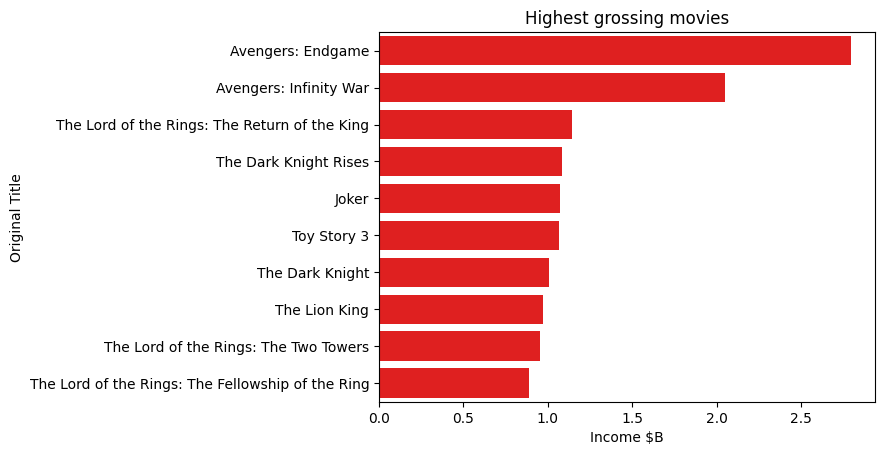

In [208]:
# highest grossing movies
df_gr_income_top_10 = df.groupby(['Original Title'])['Income'].sum().sort_values(ascending = False).reset_index()
df_gr_income_top_10 = df_gr_income_top_10.head(10)
df_gr_income_top_10['Income $B'] = df_gr_income_top_10['Income'] / 1000000000
sns.barplot(data = df_gr_income_top_10, y = 'Original Title', x = 'Income $B', color = 'red')
plt.title('Highest grossing movies')


Text(0.5, 1.0, 'Highest rating movies')

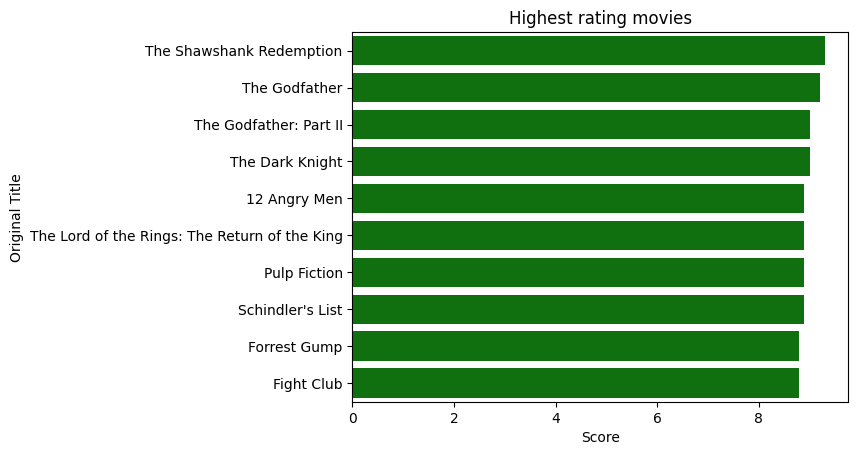

In [209]:
# highest rating movies
df_gr_score_top_10 = df.groupby(['Original Title'])['Score'].mean().sort_values(ascending = False).reset_index()
df_gr_score_top_10 = df_gr_score_top_10.head(10)
sns.barplot(data = df_gr_score_top_10, y = 'Original Title', x = 'Score', color = 'green')
plt.title('Highest rating movies')

Text(0.5, 1.0, 'Content rating distribution')

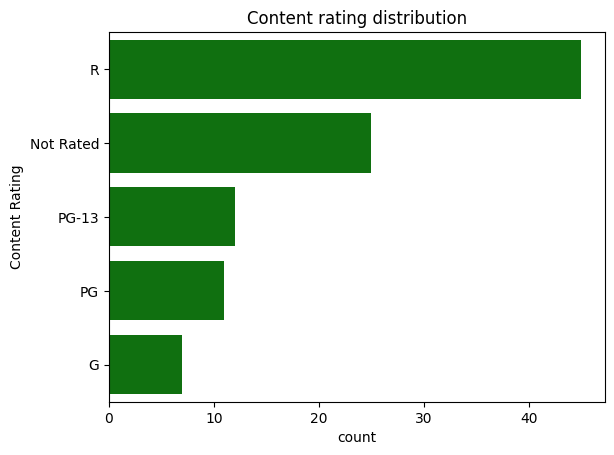

In [167]:
# count of the Content Rating
sns.countplot(data=df, y="Content Rating", order=df["Content Rating"].value_counts().index[0:100], color = 'green')
plt.title('Content rating distribution')

Text(0.5, 1.0, 'Top directors for movie production')

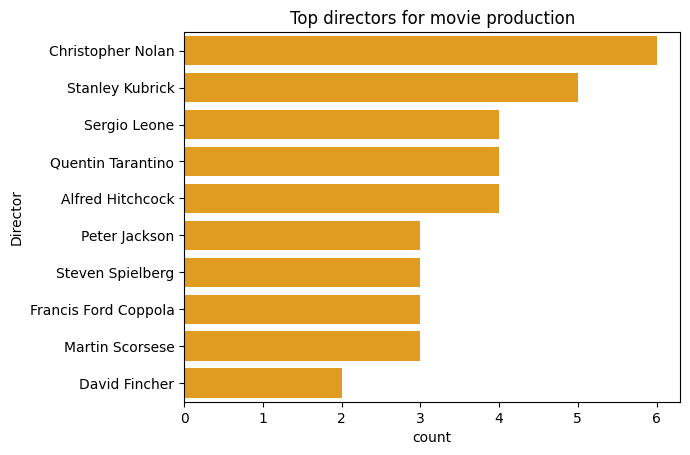

In [168]:
# top 10 directors
sns.countplot(data=df, y="Director", order=df["Director"].value_counts().index[0:10], color = 'orange')
plt.title('Top directors for movie production')

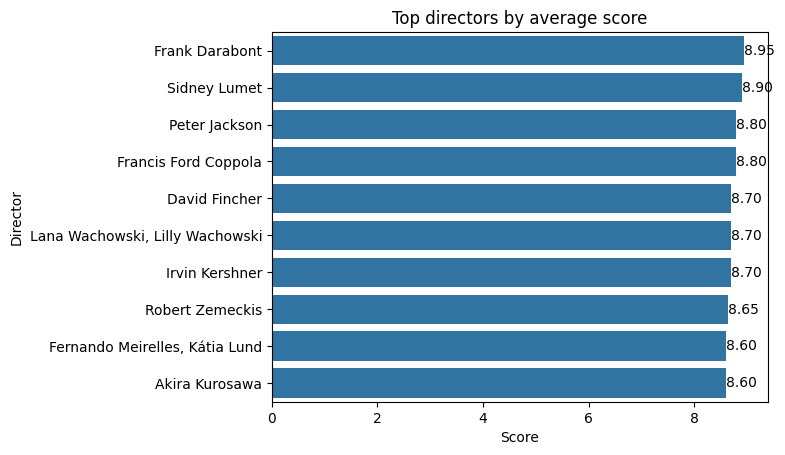

In [182]:
# top directors by the average of the score
df_gr_director_by_score_top_10 = df.groupby(['Director'])['Score'].mean().sort_values(ascending = False).reset_index()
df_gr_director_by_score_top_10 = df_gr_director_by_score_top_10.head(10)
df_gr_director_by_score_top_10['Director'] = df_gr_director_by_score_top_10['Director'].replace('Fernando Meirelles, KÃ¡tia Lund', 'Fernando Meirelles, Kátia Lund')

ax = sns.barplot(data = df_gr_director_by_score_top_10, y = 'Director', x = 'Score')
plt.title('Top directors by average score')
ax.bar_label(ax.containers[0],fmt='%.2f')
plt.show()

Text(0.5, 1.0, 'Correlation matrix')

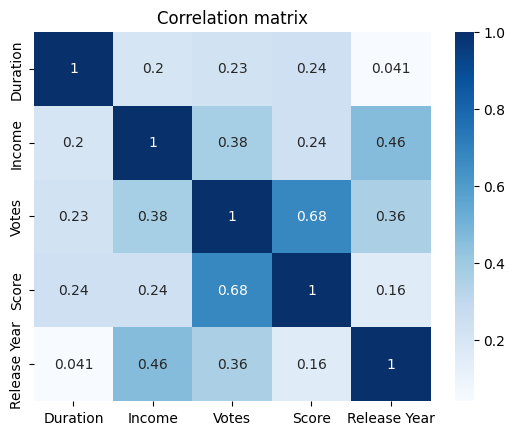

In [222]:
# building a correlation matrix to understand the correlation between the numerical entries
corr = df[["Duration", "Income", "Votes", "Score", "Release Year"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation matrix')
# the correlation Votes-Score and Income-Release Year will be studied

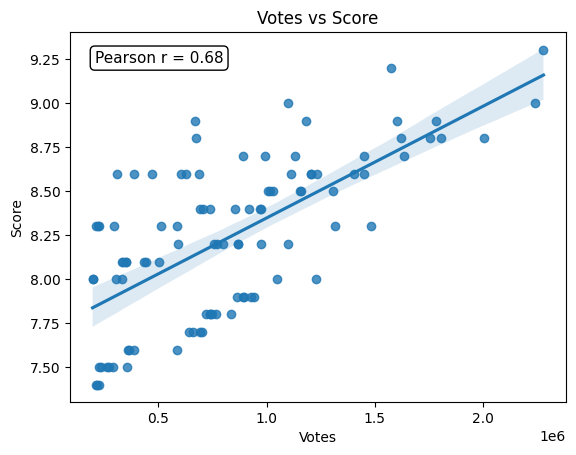

In [195]:
# correlation between votes and score
corr = df["Votes"].corr(df["Score"])
ax = sns.regplot(data=df,x="Votes",y="Score")
ax.text(0.05, 0.95,f"Pearson r = {corr:.2f}",transform=ax.transAxes,fontsize=11,verticalalignment="top",bbox=dict(boxstyle="round", facecolor="white"))
plt.title('Votes vs Score')
plt.show()
# the higher the number of votes, the higher the score

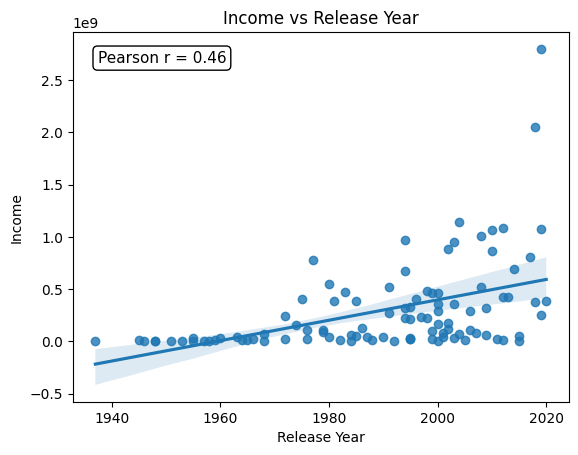

In [225]:
# correlation between Income and Release Year
corr = df["Release Year"].corr(df["Income"])
ax = sns.regplot(data=df,x="Release Year",y='Income')
ax.text(0.05, 0.95,f"Pearson r = {corr:.2f}",transform=ax.transAxes,fontsize=11,verticalalignment="top",bbox=dict(boxstyle="round", facecolor="white"))
plt.title('Income vs Release Year')
plt.show()
# slight correlation: newest movies have higher income, an inflation adjustment should be considered

Text(0.5, 1.0, 'Distribution of scores per rating')

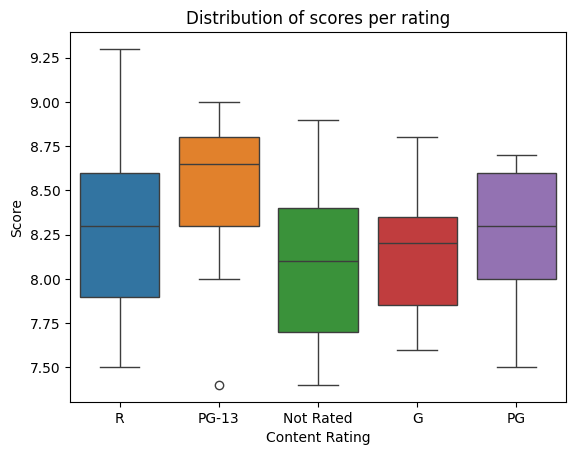

In [271]:
# distribution of score by content rating
sns.boxplot(data = df, x = 'Content Rating', y = 'Score', hue= 'Content Rating')
plt.title('Distribution of scores per rating')
# PG-13 movies has the highest average score, R-rated are the most variable with a high average

Text(0.5, 1.0, 'Count of movies by main genre')

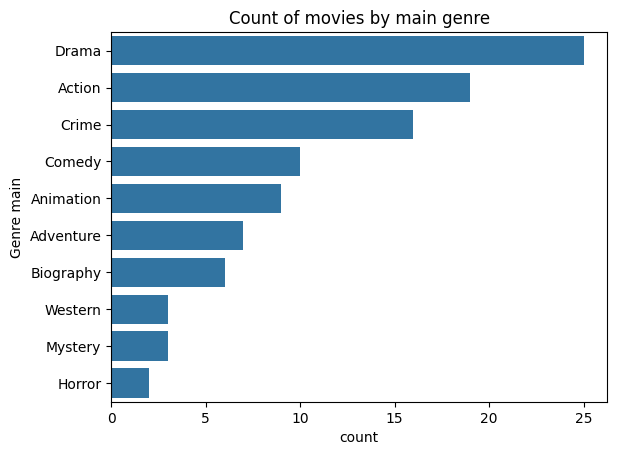

In [285]:
# ananlysis of the genre. Creating a column with only the first genre as the main
df_genre = df.copy()
df_genre['Genre_list'] = df_genre['Genre'].str.split(',')
df_genre['Genre main'] = df_genre['Genre_list'].str[0]
df_genre.head()

#
sns.countplot(data=df_genre, y="Genre main", order=df_genre["Genre main"].value_counts().index[0:10])
plt.title('Count of movies by main genre')
#

Text(0.5, 1.0, 'Distribution of Income per genre')

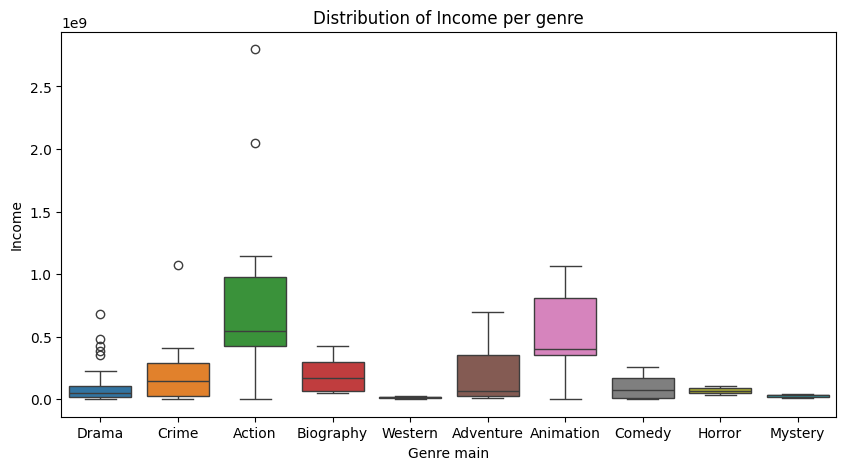

In [276]:
# distribution of income per genre
plt.figure(figsize = (10, 5))
sns.boxplot(data = df_genre, x = 'Genre main', y = 'Income', hue = 'Genre main')
plt.title('Distribution of Income per genre')

Text(0.5, 1.0, 'Distribution of Income per genre')

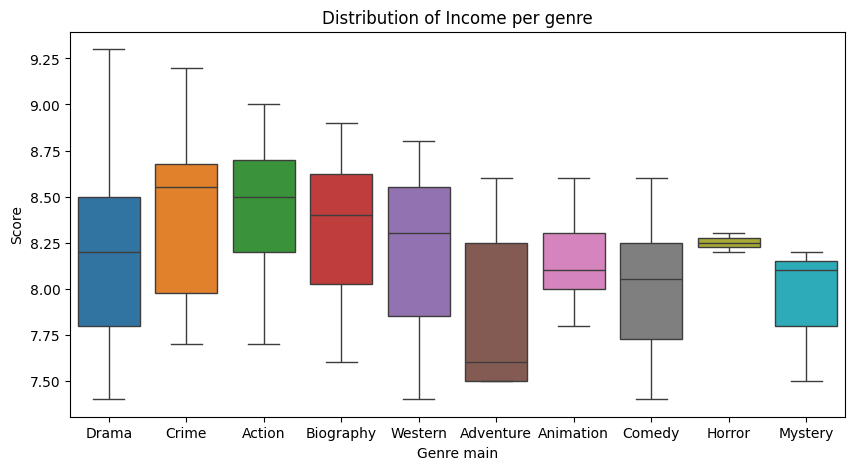

In [286]:
# distribution of income per score
plt.figure(figsize = (10, 5))
sns.boxplot(data = df_genre, x = 'Genre main', y = 'Score', hue = 'Genre main')
plt.title('Distribution of Income per genre')